In [1]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import LocalOutlierFactor
from pyod.models.abod import ABOD

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../train_set/train.csv')

In [3]:
col_to_use = [
       'numVotes', 
       'totalCredits', 
       'criticReviewsTotal',
       'userReviewsTotal', 
       'castNumber', 
       'companiesNumber',
       'writerCredits', 
       'directorsCredits', 
       'quotesTotal',
       'totalMedia', 
       'totalRecognitions',
       'averageRating'
       ]

# MinMax

In [4]:

# Standardizzazione dei dati
minMax = MinMaxScaler()
X_MinMax = minMax.fit_transform(df[col_to_use])

# LOF

In [5]:
# LOF con X_MinMax
lof = LocalOutlierFactor(n_neighbors=50, novelty=False, metric='euclidean', leaf_size=40, n_jobs=-1)
lof.fit(X_MinMax)
lof_scores = lof.negative_outlier_factor_  # Ottieni i punteggi di anomalia direttamente

In [6]:
# add columns lof_scores_MinMax and lof_scores_std to df
df['LOF'] = lof_scores

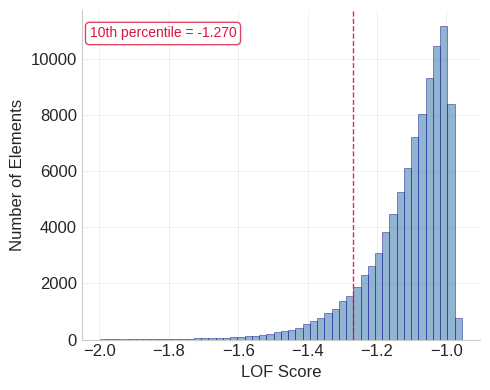

In [7]:
import numpy as np

# Set modern style
plt.style.use('seaborn-v0_8-whitegrid')

# Enhanced LOF scores histogram with percentile line
plt.figure(figsize=(5, 4))

# Calculate percentile on COMPLETE dataset (not filtered)
percentile = 10  # Change this value for desired percentile
threshold = np.percentile(lof_scores, percentile)

# Filter data ONLY for visualization (discard values < -2)
lof_scores_filtered = lof_scores[lof_scores >= -2]

# Create histogram with improved aesthetics
n, bins, patches = plt.hist(lof_scores_filtered, bins=50, alpha=0.6, 
                           color='steelblue', edgecolor='navy', linewidth=0.5)

if threshold >= -2:  # Show line only if it's in the displayed range
    plt.axvline(threshold, color='crimson', linestyle='--', linewidth=1, alpha=0.9)
    
    # Add text label at the far left of the plot
    plt.text(0.02, 0.95, f'{percentile}th percentile = {threshold:.3f}', 
             transform=plt.gca().transAxes, 
             fontsize=10, 
             color='crimson',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor='crimson'),
             verticalalignment='top')
else:
    # If percentile is out of range, add note in legend
    plt.text(0.68, 0.85, f'{percentile}th percentile = {threshold:.3f}\n(outside displayed range)', 
             transform=plt.gca().transAxes, 
             bbox=dict(boxstyle="round,pad=0.4", facecolor="gold", alpha=0.8, edgecolor='orange'),
             fontsize=10, ha='center')

plt.xlabel('LOF Score', fontsize=12)
plt.ylabel('Number of Elements', fontsize=12)


plt.grid(True, alpha=0.4, linestyle='-', linewidth=0.5)
plt.tick_params(axis='both', which='major', labelsize=12)

# Remove top and right spines for cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

plt.tight_layout()
plt.show()

# ABOD

In [8]:
abod = ABOD(n_neighbors=100, method='fast')
abod.fit(X_MinMax)
abod_scores = abod.decision_scores_  # Ottieni i punteggi di anomalia direttamente

In [9]:
 # add columns to df
df['ABOD'] = abod_scores

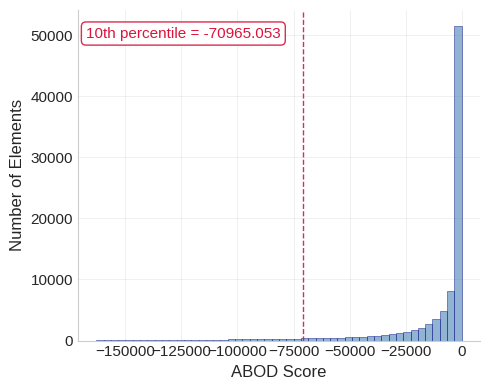

In [15]:
import numpy as np

# Set modern style
plt.style.use('seaborn-v0_8-whitegrid')

# Enhanced ABOD scores histogram with percentile line
plt.figure(figsize=(5, 4))

# Calculate percentile on COMPLETE dataset (not filtered)
percentile = 10  # For ABOD, outliers have HIGH values, so use 85th percentile
threshold = np.percentile(abod_scores, percentile)

# Filter data for visualization (remove extreme values)
min_threshold = np.percentile(abod_scores, 5)   # Remove bottom 1%
max_threshold = np.percentile(abod_scores, 100)  # Remove top 1%
abod_scores_filtered = abod_scores[(abod_scores >= min_threshold) & (abod_scores <= max_threshold)]

# Create histogram with improved aesthetics
n, bins, patches = plt.hist(abod_scores_filtered, bins=50, alpha=0.6, 
                           color='steelblue', edgecolor='navy', linewidth=0.5)

# Check if threshold is in visible range
if min_threshold <= threshold <= max_threshold:
    # Add red dashed line for percentile
    plt.axvline(threshold, color='crimson', linestyle='--', linewidth=1, alpha=0.9)
    
    # Add text label at the far left of the plot
    plt.text(0.02, 0.95, f'{percentile}th percentile = {threshold:.3f}', 
             transform=plt.gca().transAxes, 
             fontsize=11, 
             color='crimson',
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.9, edgecolor='crimson'),
             verticalalignment='top')
else:
    # If percentile is out of range, add note
    plt.text(0.5, 0.8, f'{percentile}th percentile = {threshold:.3f}\n(outside displayed range)', 
             transform=plt.gca().transAxes, 
             bbox=dict(boxstyle="round,pad=0.4", facecolor="gold", alpha=0.8, edgecolor='orange'),
             fontsize=11, ha='center')

plt.xlabel('ABOD Score', fontsize=12)
plt.ylabel('Number of Elements', fontsize=12)

plt.grid(True, alpha=0.4, linestyle='-', linewidth=0.5)
plt.tick_params(axis='both', which='major', labelsize=11)

# Remove top and right spines for cleaner look
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.8)
ax.spines['bottom'].set_linewidth(0.8)

plt.tight_layout()
plt.show()

In [11]:
df.to_csv('./train_scores_NO_IF.csv', index=False)